1. `python3.10 -m pip install ipywidgets==7.7.1 jupyterlab==3.6.3 jupyterlab-widgets==3.0.5 notebook==6.5.4 pythreejs==2.4.2 traitlets==5.9.0 widgetsnbextension jupyterlab_pygments==0.1.1  --force-reinstall --user`
1. `sudo apt install nodejs npm`
1. `jupyter lab build`

# Init

In [1]:
#   0
#   1
#   2
#   3
#   4
#   5
#   6
#   7
#   8
#   9
#  10
#  11
#  12
#  13
#  14, 
#  15
#  16
#  17
#  18
#  19
#  20
#  21
#  22
#  23
#  24
#  25
#  26
#  27
#  28
#  29
#  30
#  31
#  32
#  33
#  34
#  35
#  36,
#  37
#  38
#  39
#  40
#  41
#  42
#  43
#  44
#  45, 
#  46
#  47
#  48
#  49
#  50
#  51
#  52
#  53
#  54
#  55
#  56
#  57
#  58
#  59
#  60
#  61
#  62
#  63
#  64
#  65
#  66
#  67
#  68
#  69
#  70, 2026-01-29 - OKAY
#  71
#  72
#  73
#  74
#  75
#  76
#  77
#  78
#  79, 2026-01-29 - OKAY
#  80, 2026-02-02 - OKAY
#  81
#  82
#  83, 
#  84
#  85
#  86
#  87
#  88
#  89
#  90
#  91
#  92
#  93, 2026-02-03 - OKAY
#  94
#  95, 2026-02-03 - OKAY
#  96, 2026-02-03 - OKAY
#  97
#  98
#  99
# 100
# 101
# 102
# 103, 2026-02-03 - MISSING A RED SHOT at ITER 9
# 104
# 105, 2026-02-03 - OKAY
# 106
# 107, 2026-02-03 - OKAY
# 108, 2026-02-03 - OKAY
# 109, 2026-02-03 - OKAY
# 110, 2026-02-03 - OKAY
# 111, 2026-02-03 - White in wrong place
# 112, 2026-02-03 - OKAY
# 113, 2026-02-03 - OKAY
# 114
# 115, 2026-02-03 - OKAY
# 116
# 117
# 118
# 119, 2026-02-03 - OKAY
# 120
# 121
# 122, 2026-02-03 - OKAY
# 123
# 124
# 125, 2026-02-03 - OKAY
# 126,
# 127,
# 128
# 129, 2026-02-03 - OKAY
# 130
# 131 
# 132, 2026-02-03 - OKAY
# 133, 2026-02-03 - OKAY
# 134, 2026-02-03 - OKAY
# 135, 2026-02-03 - OKAY
# 136
# 137
# 138
# 139
# 140
# 141
# 142
# 143
# 144, 2026-02-03 - OKAY
# 145
# 146, 2026-02-03 - OKAY
# 147, 2026-02-04 - OKAY
# 148, 2026-02-04 - OKAY
# 149, 2026-02-04 - OKAY
# 150, 2026-02-04 - OKAY
# 151, 2026-02-04 - OKAY
# 152, 2026-02-04 - OKAY
# 153, 2026-02-04 - OKAY
# 154, 2026-02-04 - OKAY
# 155, 2026-02-04 - OKAY
# 156, 2026-02-04 - OKAY
# 157, 2026-02-04 - OKAY
# 158, 2026-02-04 - OKAY
# 159, 2026-02-04 - OKAY
# 160
# 161, 2026-02-04 - OKAY
_EXP_INDEX = 161

In [2]:
print( f'Experiment Index: {_EXP_INDEX}' )

Experiment Index: 161


In [3]:
########## INIT ####################################################################################
import pickle, os, traceback, json
from collections import deque
from copy import deepcopy
from pprint import pprint
from typing import Deque

import numpy as np
import matplotlib.pyplot as plt

from magpie_control.ur5 import _CAMERA_XFORM

from aspire.env_config import env_var
from aspire.symbols import GraspObj, ObjPose, euclidean_distance_between_symbols, extract_pose_as_homog
from aspire.BlocksTask import set_blocks_env

from TaskPlanner import set_experiment_env
from draw_jupyter import set_render_env
from utils import deep_copy_memory_list

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [4]:
##### Environment && Constants ############################################
set_blocks_env()
set_experiment_env()
set_render_env()

In [5]:
########## SETUP ###################################################################################
_JSON_PATH  = "data/allData.txt"

# _DATA_DRIVE = "DATA_TANK"
_DATA_DRIVE = "STARGAZER/DATA_TANK"

_PLOT_DIR   = "/media/james/FILEPILE/EROM/data/plots/"
# _PLOT_DIR   = "data/plots/"

_RAM_SAVER = False

tests = [
    "KC-KP",
    "SC-KP",
    "KC-SP",
    "SC-SP",
]

longTestNames = [
    "Known Class & Known Pose", 
    "Sensed Class & Known Pose", 
    "Known Class & Sensed Pose", 
    "Sensed Class & Sensed Pose", 
]

# paths = [ f"/media/james/{_DATA_DRIVE}/2025-08_{test}" for test in tests ]
datasets = [
    [ f"/media/james/{_DATA_DRIVE}/2025-08B_{test}" for test in tests ],
    [ f"/media/james/{_DATA_DRIVE}/RWB_2025-09_{test}" for test in tests ],
]

dataLabels = ["RGB", "RBW",]
datNamLong = {
    "RGB": "Red-Green-Blue", 
    "RBW": "Red-Black-White",
}

fNames = [ f"{_PLOT_DIR}{test}" for test in tests  ]

plotExt = ".pdf"

pkls = deque()

for iii, paths in enumerate( datasets ):
    setNam = dataLabels[iii]
    suffix = "_" + setNam
    skip   = False

    for ii, test in enumerate( tests ):
        ##### Init ################################################################
        path     = paths[ii]
        fName    = fNames[ii]
        longTNam = longTestNames[ii]

        ##### Load ################################################################
        try:
            pkls.extend( [os.path.join( path, item ) for item in sorted( os.listdir( path ) ) if ((".pkl" in f"{item}".lower()) and ("_OCV-State" not in f"{item}"))] )
        except FileNotFoundError as e:
            print( f"\n404, SKIP THIS TEST: {e}\n" )
            skip = True
            continue

In [6]:
########## HELPER FUNCTIONS ########################################################################
_TITLE_FONT_SIZE = 13
_N_TRIALS        = 20
_TIGHT_MARGIN    =  0.05

In [7]:
def camPose_from_effPose( effPose : np.ndarray ):
    """ Get the camera pose given the effector pose """
    return np.dot( effPose, _CAMERA_XFORM )


def filter_series( series, stdFactor = 2.0 ):
    """ Filter outliers more than `stdFactor` standard deviations from the mean """
    if not len( series ):
        return list()
    mu = np.mean( series )
    sd = np.std( series )
    nuSeries = deque()
    thresh   = abs(sd*stdFactor)
    for datum in series:
        if abs( datum - mu ) <= thresh:
            nuSeries.append( datum )
    return list( nuSeries )


def as_json( dataObj, asLeaf = False ):
    """ Convert the dataclass into a struct that can be JSON serialized """
    def make_serializable( obj, depth = 0 ):
        nonlocal asLeaf
        if isinstance( obj, (deque, list,) ):
            rtnLst = deque()
            for item in obj:
                rtnLst.append( make_serializable( item, depth+1 ) )
            return list( rtnLst )
        elif isinstance( obj, np.ndarray ):
            return obj.tolist()
        elif isinstance( obj, dict ):
            rtnDct = dict()
            for k, v in obj.items():
                rtnDct[k] = make_serializable( v, depth+1 )
            return rtnDct
        else:
            return obj
    rtnObj = make_serializable( dataObj, 0 )
    return rtnObj


def crash_out():
    """ End the program with Brutal Finality """
    print( "\n\n" )
    os.system( 'kill %d' % os.getpid() ) 


def extract_pose_from_str( poseStr : str ):
    """ Get the homogeneous coordinates from the string and ignore everything else """
    nstLst = list()
    depth  = 0
    numStr = ""
    row    = list()

    def store_num():
        """ Add the number to the row """
        nonlocal row, numStr, poseStr
        if len( numStr ):
            try:
                row.append( float( numStr.strip() ) )
            except ValueError as e:
                print( f"BAD: {e}" )
                print( numStr  )
                print( poseStr )
                crash_out()
        numStr = ""

    def store_row():
        """ Add the row to the array """
        nonlocal nstLst, row
        if len( row ):
            nstLst.append( row )
        row = list()

    for char in poseStr:
        if char == '[':
            depth += 1
        elif char == ']':
            if depth == 2:
                store_num()
            depth -= 1
            if depth == 1:
                store_row()
        elif char == ' ':
            if depth == 2:
                store_num()
        elif char == '\n':
            pass
        elif depth == 2:
            numStr += char
        else:
            pass
            # print( f"`extract_pose_from_str()`, BAD STATE:\n{char}\n{poseStr}\n" )

    try:
        return np.array( nstLst )
    except Exception as e:
        traceback.print_exc()
        print( f"BAD: {e}" )
        crash_out()


def sum_dicts( dct0 : dict, dct1 : dict ):
    """ Return the sum of numeric values """
    rtnDct = dict()
    for dct in [dct0, dct1,]:
        for k, v in dct.items():
            if k in rtnDct:
                tot = 0
                try:
                    tot = v + rtnDct[k]
                except Exception as e:
                    pass
                rtnDct[k] = tot
            else:
                rtnDct[k] = v
    return rtnDct
        

In [8]:
class TColor:
    """ Terminal Colors """
    # Source: https://stackoverflow.com/a/287944
    HEADER    = '\033[95m'
    OKBLUE    = '\033[94m'
    OKCYAN    = '\033[96m'
    OKGREEN   = '\033[92m'
    WARNING   = '\033[93m'
    FAIL      = '\033[91m'
    ENDC      = '\033[0m'
    BOLD      = '\033[1m'
    UNDERLINE = '\033[4m'

# Load File(s)

In [9]:
print( f"Found {len(pkls)} files!" ) 


Found 1686 files!


# "Ground Truth" Annotator

In [10]:
from State import OCV_State_Tracker


# Inspect File

Experiment Index: 400 / 1685
Looking for ['redBlock', 'grnBlock', 'bluBlock']
Experiment Index: 401 / 1685
Looking for ['redBlock', 'grnBlock', 'bluBlock']
Experiment Index: 402 / 1685
Looking for ['redBlock', 'grnBlock', 'bluBlock']
Experiment Index: 403 / 1685
Looking for ['redBlock', 'grnBlock', 'bluBlock']
LOAD SUCCESS: /media/james/STARGAZER/DATA_TANK/2025-08B_KC-SP/EROM-Memories_08-27-2025_19-16-25.pkl
`Memory` initialized ...

MESSAGE: RobotState

Moved to [-0.25193 -0.262 0.47104]

MESSAGE: RobotState

Moved to [-0.25193 -0.262 0.47104]

MESSAGE: Task Start


MESSAGE: Performance


MESSAGE: Performance


MESSAGE: BGN: Phase 1


########## Iteration 1 ######################################################

MESSAGE: Performance


MESSAGE: RobotState

Moved to [-0.25199 -0.26201 0.47097]

MESSAGE: RobotState

Moved to [-0.33346 -0.22509 0.38476]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

There are 3 images at this pose!


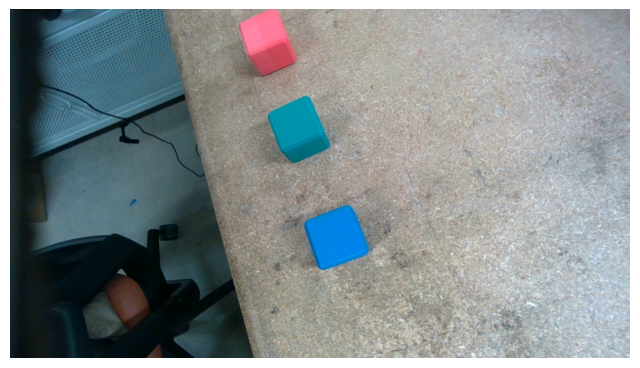

Density: 0.581858407079646, Ratio: 0.8955823293172691
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (7467, 3)
Points Array with shape: (7467, 3)
Transformed 7467 points!
redBlock can be found at <GraspObj 4:4 @ [-0.37066 0.015928 0.02939], Class: redBlock, Prob: 0.0000>
Density: 0.6101176470588235, Ratio: 0.9003831417624522
Density: 0.39704739704739705, Ratio: 0.7222222222222222
MASK FOUND for grnBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (9686, 3)
Points Array with shape: (9686, 3)
Transformed 9686 points!
grnBlock can be found at <GraspObj 5:5 @ [-0.3762 -0.079866 0.033826], Class: grnBlock, Prob: 0.0000>
Density: 0.652508136011671, Ratio: 0.8951310861423221
Density: 0.336734693877551, Ratio: 0.7857142857142857
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (10573, 3)
Points Array with shape: (10573, 3)
Transformed 10573 points!

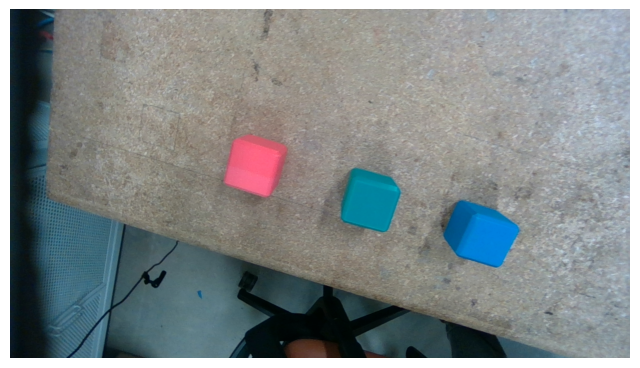

Density: 0.7075990501187351, Ratio: 0.9209486166007905
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (6954, 3)
Points Array with shape: (6954, 3)
Transformed 6954 points!
redBlock can be found at <GraspObj 7:7 @ [-0.37455 0.020616 0.032306], Class: redBlock, Prob: 0.0000>
Density: 0.712, Ratio: 0.9260700389105059
Density: 0.27429577464788735, Ratio: 0.6335078534031413
Density: 0.3053571428571429, Ratio: 0.6987951807228916
MASK FOUND for grnBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (10538, 3)
Points Array with shape: (10538, 3)
Transformed 10538 points!
grnBlock can be found at <GraspObj 8:8 @ [-0.37893 -0.076122 0.035874], Class: grnBlock, Prob: 0.0000>
Density: 0.6469491073807621, Ratio: 0.9269102990033222
Density: 0.3438735177865613, Ratio: 0.8
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (12052, 3)
Points Array with shape: (

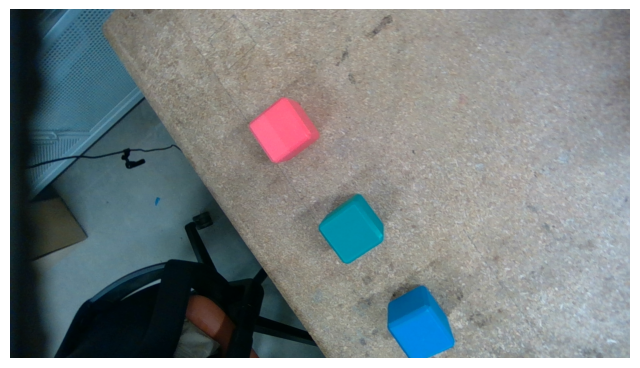

Density: 0.5984642457206847, Ratio: 0.9598540145985401
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (7897, 3)
Points Array with shape: (7897, 3)
Transformed 7897 points!
redBlock can be found at <GraspObj 10:10 @ [-0.37056 0.020347 0.035521], Class: redBlock, Prob: 0.0000>
Density: 0.6023310023310023, Ratio: 0.960431654676259
Density: 0.3710144927536232, Ratio: 0.5094339622641509
MASK FOUND for grnBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (11349, 3)
Points Array with shape: (11349, 3)
Transformed 11349 points!
grnBlock can be found at <GraspObj 11:11 @ [-0.37608 -0.075851 0.034524], Class: grnBlock, Prob: 0.0000>
Density: 0.7140287769784173, Ratio: 0.953405017921147
Density: 0.45625, Ratio: 0.9230769230769231
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (11695, 3)
Points Array with shape: (11695, 3)
Transformed 11695 points!
b

Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1

Observation took 63.25 seconds!

3 Pre-Cheat Symbols
[<GraspObj 56:56 @ [-0.37643 -0.16961 0.030698], Class: bluBlock, Prob: 0.5081>, <GraspObj 57:57 @ [-0.3797 -0.074734 0.031754], Class: grnBlock, Prob: 0.4136>, <GraspObj 58:58 @ [-0.37027 0.013786 0.028317], Class: redBlock, Prob: 0.6283>]

MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2

3 Post-Cheat Symbols
[<GraspObj 146:146 @ [-0.37643 -0.16961 0.030698], Class: bluBlock, Prob: 0.5081>, <GraspObj 147:147 @ [-0.3797 -0.074734 0.031754], Class: grnBlock, Prob: 0.4136>, <GraspObj 148:148 @ [-0.37027 0.013786 0.028317], Class: redBlock, Prob: 0.6283>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Processed 9 readings!
3 "Ground Truth" Symbols
[<GraspObj 4:4 @ [-0.37127 0.017562 0.02], Class: redBlock, Prob: 0.0000>, <GraspObj 5:5 @ [-0.37662 -0.078464 0.02], Class: grnBlock, Prob: 0.0000>, <GraspObj 6:6 @ [-0.38151 -0.17461 0.02], Class: bluBlock, Prob: 0.0000>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Scene Confusion: {'N_total': 3, 'N_confuse': 0, 'N_halluc': 0, 'N_missing': 0, 'N_sensed': 3, 'N_true': 3}

MESSAGE: Performance


MESSAGE: Validate Goal State


MESSAGE: BGN: Phase 3


MESSAGE: Annotation


MESSAGE: END: Phase 3


MESSAGE: Performance


MESSAGE: BGN: Phase 4


MESSAGE: RobotState

Moved to [-0.27045 -0.032975 0.38475]

MESSAGE: BT BEGIN: 1756343859.2129087


MESSAGE: RobotState

Moved to [-0.27044 -0.032973 0.38476]

MESSAGE: Behavior: Move_Arm, Status.RUNNING


MESSAGE: RobotState

Moved to [-0.27443 -0.027469 0.34999]

MESSAGE: RobotState

Moved to [-0.38368 -0.069216 0.35002]

MESSAGE: RobotState

Moved to [-0.38369 -0.069237 0.26185]

MESSAGE: RobotState

Moved to [-0.38369 -0.069211 0.35]

MESSAGE: RobotState

Moved to [-0.204 -0.29449 0.34999]

MESSAGE: Behavior: Open_Gripper, Status.SUCCESS


MESSAGE: BT END: Status.SUCCESS


MESSAGE: Action Success: , 1756343876.9482868


MESSAGE: Annotation


MESSAGE: END: Phase 4


MESSAGE: Performance


MESSAGE: BGN: Phase 

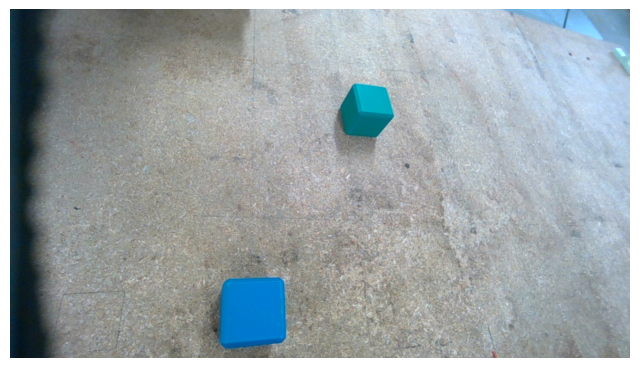

Density: 0.7508627219930982, Ratio: 0.9724770642201835
Density: 0.30158730158730157, Ratio: 0.875
MASK FOUND for grnBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (7668, 3)
Points Array with shape: (7668, 3)
Transformed 7668 points!
grnBlock can be found at <GraspObj 13:13 @ [-0.20884 -0.29555 0.028457], Class: grnBlock, Prob: 0.0000>
Density: 0.890813879508638, Ratio: 0.972027972027972
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (14633, 3)
Points Array with shape: (14633, 3)
Transformed 14633 points!
bluBlock can be found at <GraspObj 14:14 @ [-0.38536 -0.17677 0.038105], Class: bluBlock, Prob: 0.0000>

Added 2 readings!



MESSAGE: Observation END


MESSAGE: RobotState

Moved to [-0.25198 -0.26208 0.4709]

MESSAGE: RobotState

Moved to [-0.51024 -0.0029638 0.37702]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

There are 3 images at this pose!


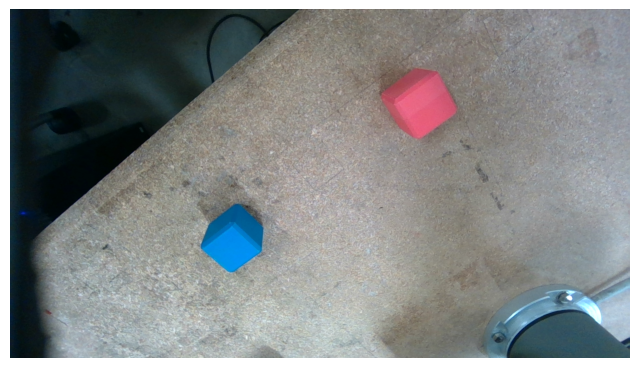

Density: 0.6260143643316854, Ratio: 0.9692832764505119
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (7546, 3)
Points Array with shape: (7546, 3)
Transformed 7546 points!
redBlock can be found at <GraspObj 15:15 @ [-0.37068 0.025741 0.030807], Class: redBlock, Prob: 0.0000>
Density: 0.37815126050420167, Ratio: 0.9354838709677419
Density: 0.6419642857142858, Ratio: 0.9664179104477612
Density: 0.36428571428571427, Ratio: 0.9629629629629629
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (10421, 3)
Points Array with shape: (10421, 3)
Transformed 10421 points!
bluBlock can be found at <GraspObj 16:16 @ [-0.38303 -0.16925 0.031215], Class: bluBlock, Prob: 0.0000>

Added 2 readings!



MESSAGE: Observation END


MESSAGE: RobotState

Moved to [-0.2519 -0.26202 0.47105]

MESSAGE: RobotState

Moved to [-0.51027 -0.0029453 0.37697]

MESSAGE: Observation BEGIN


MESSAGE: Annotation




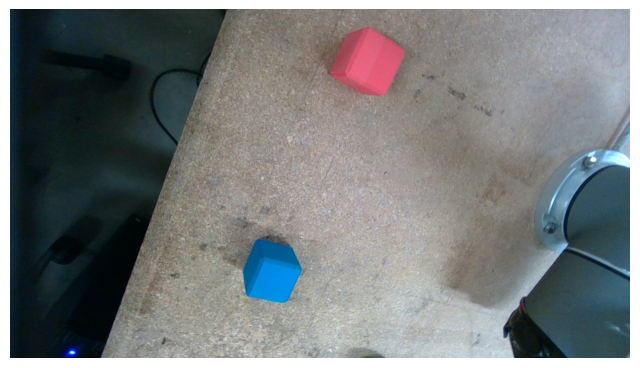

Density: 0.6577220077220077, Ratio: 0.9479166666666666
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (9059, 3)
Points Array with shape: (9059, 3)
Transformed 9059 points!
redBlock can be found at <GraspObj 17:17 @ [-0.37476 0.025432 0.032253], Class: redBlock, Prob: 0.0000>
Density: 0.2683333333333333, Ratio: 0.56
Density: 0.7211369897320311, Ratio: 0.9604743083003953
Density: 0.5500821018062397, Ratio: 0.68
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (8574, 3)
Points Array with shape: (8574, 3)
Transformed 8574 points!
bluBlock can be found at <GraspObj 18:18 @ [-0.38477 -0.16856 0.034007], Class: bluBlock, Prob: 0.0000>

Added 2 readings!



MESSAGE: memory

Post-Search Beliefs


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1

Observation took 46.01 seconds!

3 Pre-Cheat Symbols
[<GraspObj 250:250 @ [-0.21093 -0.29246 0.027395], Class: grnBlock, Prob: 0.4103>, <GraspObj 251:251 @ [-0.38269 -0.16539 0.027442], Class: bluBlock, Prob: 0.5601>, <GraspObj 252:252 @ [-0.37421 0.027196 0.033412], Class: redBlock, Prob: 0.5139>]

MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2

3 Post-Cheat Symbols
[<GraspObj 340:340 @ [-0.21093 -0.29246 0.027395], Class: grnBlock, Prob: 0.4103>, <GraspObj 341:341 @ [-0.38269 -0.16539 0.027442], Class: bluBlock, Prob: 0.5601>, <GraspObj 342:342 @ [-0.37421 0.027196 0.033412], Class: redBlock, Prob: 0.5139>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Processed 6 readings!
3 "Ground Truth" Symbols
[<GraspObj 13:13 @ [-0.20884 -0.29555 0.02], Class: grnBlock, Prob: 0.0000>, <GraspObj 14:14 @ [-0.38487 -0.17393 0.02], Class: bluBlock, Prob: 0.0000>, <GraspObj 15:15 @ [-0.37149 0.025679 0.02], Class: redBlock, Prob: 0.0000>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Scene Confusion: {'N_total': 3, 'N_confuse': 0, 'N_halluc': 0, 'N_missing': 0, 'N_sensed': 3, 'N_true': 3}

MESSAGE: Performance


MESSAGE: Validate Goal State


MESSAGE: BGN: Phase 3


MESSAGE: Annotation


MESSAGE: END: Phase 3


MESSAGE: Performance


MESSAGE: BGN: Phase 4


MESSAGE: RobotState

Moved to [-0.51022 -0.0029633 0.37698]

MESSAGE: BT BEGIN: 1756343929.3305013


MESSAGE: RobotState

Moved to [-0.51023 -0.0029684 0.37702]

MESSAGE: Behavior: Move_Arm, Status.RUNNING


MESSAGE: RobotState

Moved to [-0.51424 0.0025571 0.35002]

MESSAGE: RobotState

Moved to [-0.37821 0.032709 0.34997]

MESSAGE: RobotState

Moved to [-0.3782 0.032705 0.26349]

MESSAGE: RobotState

Moved to [-0.37821 0.03273 0.35004]

MESSAGE: RobotState

Moved to [-0.21489 -0.28694 0.35001]

MESSAGE: Behavior: Open_Gripper, Status.SUCCESS


MESSAGE: BT END: Status.SUCCESS


MESSAGE: Action Success: , 1756343947.4670436


MESSAGE: Annotation


MESSAGE: END: Phase 4


MESSAGE: Performance


MESSAGE: BGN: Phas

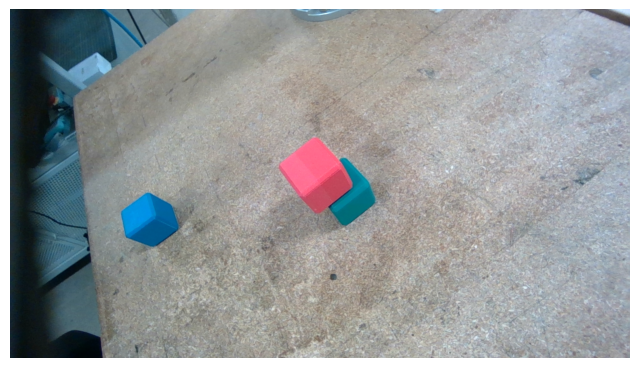

Density: 0.5632564714197367, Ratio: 0.9401993355481728
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (8797, 3)
Points Array with shape: (8797, 3)
Transformed 8797 points!
redBlock can be found at <GraspObj 19:19 @ [-0.20844 -0.30211 0.070808], Class: redBlock, Prob: 0.0000>
Density: 0.40442768909922194, Ratio: 0.6228070175438597
MASK FOUND for grnBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (5156, 3)
Points Array with shape: (5156, 3)
Transformed 5156 points!
grnBlock can be found at <GraspObj 20:20 @ [-0.19516 -0.31553 0.027382], Class: grnBlock, Prob: 0.0000>
Density: 0.6735747303543914, Ratio: 0.9824561403508771
Density: 0.284688995215311, Ratio: 0.8292682926829268
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (7311, 3)
Points Array with shape: (7311, 3)
Transformed 7311 points!
bluBlock can be found at <GraspObj 21:21 @ [-0.377

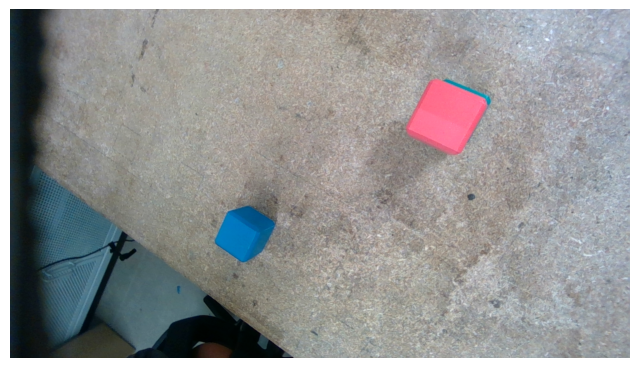

Density: 0.6104698094930578, Ratio: 0.8888888888888888
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (10765, 3)
Points Array with shape: (10765, 3)
Transformed 10765 points!
redBlock can be found at <GraspObj 22:22 @ [-0.2147 -0.2978 0.073779], Class: redBlock, Prob: 0.0000>
Density: 0.6333753854779927, Ratio: 0.9372384937238494
Density: 0.45714285714285713, Ratio: 0.9090909090909091
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (8418, 3)
Points Array with shape: (8418, 3)
Transformed 8418 points!
bluBlock can be found at <GraspObj 23:23 @ [-0.38116 -0.17874 0.031592], Class: bluBlock, Prob: 0.0000>

Added 2 readings!



MESSAGE: Observation END


MESSAGE: RobotState

Moved to [-0.2521 -0.26197 0.47099]

MESSAGE: RobotState

Moved to [-0.49751 -0.22644 0.37116]

MESSAGE: Observation BEGIN


MESSAGE: Annotation


MESSAGE: ObsMeta

There are 3 images at this pose!


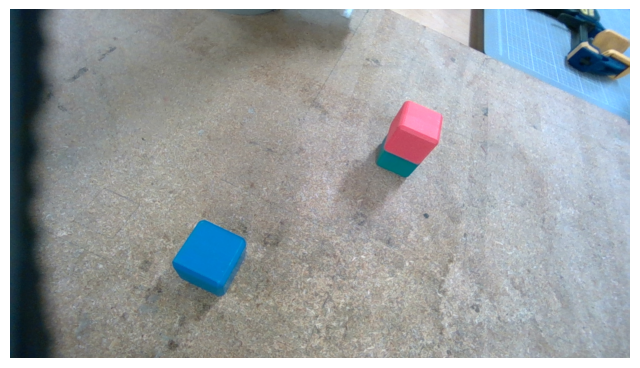

Density: 0.3926197259530593, Ratio: 0.5473251028806584
MASK FOUND for redBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (4028, 3)
Points Array with shape: (4028, 3)
Transformed 4028 points!
redBlock can be found at <GraspObj 24:24 @ [-0.2203 -0.29154 0.062012], Class: redBlock, Prob: 0.0000>
Density: 0.4783389450056117, Ratio: 0.7867647058823529
Density: 0.619475371120108, Ratio: 0.9318181818181818
Density: 0.28888888888888886, Ratio: 0.7894736842105263
MASK FOUND for bluBlock!
(720, 1280, 3)
(720, 1280)
(720, 1280, 3)
(720, 1280)
Points Array with shape: (12315, 3)
Points Array with shape: (12315, 3)
Transformed 12315 points!
bluBlock can be found at <GraspObj 25:25 @ [-0.38386 -0.17804 0.037888], Class: bluBlock, Prob: 0.0000>

Added 2 readings!



MESSAGE: memory

Post-Search Beliefs


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…


MESSAGE: symbols


MESSAGE: Observation END


MESSAGE: END: Phase 1

Observation took 59.29 seconds!

4 Pre-Cheat Symbols
[<GraspObj 673:673 @ [-0.38347 -0.18494 0.03272], Class: bluBlock, Prob: 0.5339>, <GraspObj 674:674 @ [-0.19552 -0.31675 0.030066], Class: bluBlock, Prob: 0.4356>, <GraspObj 675:675 @ [-0.22002 -0.29276 0.069477], Class: redBlock, Prob: 0.4571>, <GraspObj 676:676 @ [-0.22387 -0.29737 0.017784], Class: grnBlock, Prob: 0.4645>]

MESSAGE: BGN: Phase 2


MESSAGE: symbols


MESSAGE: Pre-Cheat


MESSAGE: Post-Cheat


MESSAGE: Conditions Grounded


MESSAGE: Annotation


MESSAGE: END: Phase 2

4 Post-Cheat Symbols
[<GraspObj 1009:1009 @ [-0.38347 -0.18494 0.03272], Class: bluBlock, Prob: 0.5339>, <GraspObj 1010:1010 @ [-0.19552 -0.31675 0.030066], Class: grnBlock, Prob: 0.4356>, <GraspObj 1011:1011 @ [-0.22002 -0.29276 0.069477], Class: redBlock, Prob: 0.4571>, <GraspObj 1012:1012 @ [-0.22387 -0.29737 0.017784], Class: grnBlock, Prob: 0.4645>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Processed 7 readings!
3 "Ground Truth" Symbols
[<GraspObj 19:19 @ [-0.21181 -0.2993 0.06], Class: redBlock, Prob: 0.0000>, <GraspObj 20:20 @ [-0.19516 -0.31553 0.02], Class: grnBlock, Prob: 0.0000>, <GraspObj 21:21 @ [-0.37923 -0.18004 0.02], Class: bluBlock, Prob: 0.0000>]


Renderer(camera=PerspectiveCamera(aspect=1.618, far=10.0, fov=70.0, position=(-0.468, -0.54375, 0.282500000000…

Scene Confusion: {'N_total': 4, 'N_confuse': 0, 'N_halluc': 1, 'N_missing': 0, 'N_sensed': 4, 'N_true': 3}


RuntimeError: PLEASE STOP

In [11]:
from random import choice
from uuid import uuid4

from IPython.display import clear_output

from Memory import Memory
from utils import JupyterPlotServer
from draw_jupyter import render_memory_list
from homog_utils import posn_from_xform

_MEM_IMG_DIR = "data/MemImg"
_SAFE_POSN   = np.array( [-0.25199, -0.26192, 0.47106,] ) 
_VERBOSE     = True # False
_CHK_OUT     = True

for _EXP_INDEX in range( 400, len(pkls) ): 

    print( f'Experiment Index: {_EXP_INDEX} / {len(pkls)-1}' )

    pklFile    = pkls[ _EXP_INDEX ]
    ocvTracker = OCV_State_Tracker( pklFile )

    if "RWB" in f"{pklFile}".upper():
        _BLOCK_NAMES = ['redBlock','blkBlock','whtBlock',]
    else:
        _BLOCK_NAMES = ['redBlock','grnBlock','bluBlock',]
    
    print( f"Looking for {_BLOCK_NAMES}" )
    
    data = list()
    if "Thin" in pklFile:
        continue
    try:
        with open( pklFile, 'rb' ) as f:
            data = pickle.load( f )
            print( f"LOAD SUCCESS: {pklFile}" )
    except EOFError as e:
        print( f"LOAD ERROR: {e}" )

    memory = Memory( suppressRecord = True ) 
    jps    = JupyterPlotServer()
    
    ### Steps ###
    Nstep    = 0
    tStepBgn = 0
    tStepEnd = 0
    tStepDqu = deque()
    
    ### 1. Object Search ###
    shotPoses = list()
    
    ### 2. Symbol Grounding ###
    Nground    = 0
    tGroundBgn = 0
    tGroundEnd = 0
    tGroundDqu = deque()
    symbols_t  = list()
    totFound   = 0
    totConfuse = 0
    NfailFind  = 0
    
    ### 3. Planning ###
    Nplan     = 0
    tPlanBgn  = 0
    tPlanEnd  = 0
    tPlanDqu  = deque()
    NfailPlan = 0
    pNewStep  = False # Has a new step begun?
    pTryPlan  = False # Did we try to plan this step?
    
    ### 4. Acting ###
    Naction    = 0
    tActionBgn = 0
    tActionEnd = 0
    tActionDqu = deque()
    NfailActn  = 0
    actionFail = False
    
    ### N. Analysis ###
    totlConf = {
        "N_total"  : 0,
        "N_confuse": 0,
        "N_halluc" : 0,
        "N_missing": 0,
    }
    
    
    ##### Per-Message Accounting #####
    # ASSUMPTION: "BGN: ..." / "END: ..." MESSAGES ALWAYS APPEAR IN THE CORRECT ORDER! 
    for datum in data:
        try:
            dtmMsg = datum['msg']
            dtmT   = datum['t']
            dtmDat = datum['data']
        except KeyError:
            print( f'Bad keys!' )
            continue
    
        print( f"\n{TColor.OKBLUE}MESSAGE: {dtmMsg}{TColor.ENDC}\n" ) 
    
        ##### General State ###################################
    
        if "RobotState" in dtmMsg:
            pose_t = np.array( dtmDat['pose'] )
            posn_t = posn_from_xform( pose_t )
            print( f"Moved to {posn_t}" )
            # if np.linalg.norm( posn_t - _SAFE_POSN ) > env_var("_ACCEPT_POSN_ERR"):
            #     shotPoses.append( pose_t )  
            shotPoses.append( pose_t )  
    
        
        ##### Phase 1: Perception #############################
        
        if "BGN: Phase 1" in dtmMsg:
            # ASSUMPTION: PHASE 1 MESSAGE SENT ONLY ONCE PER STEP, See `p1pp2`
            Nstep += 1
            if tStepBgn > 0:
                tStepEnd = dtmT
                print( f"Last iteration took {tStepEnd-tStepBgn:.2f} seconds!" )
            tStepBgn   = dtmT
            tSearchBgn = dtmT
            print( f"\n{TColor.OKGREEN}########## Iteration {Nstep} ######################################################{TColor.ENDC}" )
            # WARNING: THIS SMELLS
            if pNewStep and (not pTryPlan):
                NfailFind += 1
                # symHst.ingest_empty()
            pNewStep   = True
            pTryPlan   = False
            actionFail = False
            ocvTracker.new_scene()
    
        if "ObsMeta"  in dtmMsg:
            inpt = dtmDat['input']
            if _VERBOSE:
                print( f"There are {len( list( inpt.keys() ) )} images at this pose!" )
                imag = inpt[ choice( list( inpt.keys() ) ) ]['image']
                if not _RAM_SAVER:
                    jps.arr_show( imag )
            ocvTracker.process_observation_data( dtmDat, _BLOCK_NAMES, camPose_from_effPose( shotPoses[-1] ), timestep = dtmT )
    
        if "memory" in dtmMsg:
            if _VERBOSE:
                print( "Post-Search Beliefs" )
                if not _RAM_SAVER:
                    render_memory_list( dtmDat["beliefs"], robotPose = shotPoses )
        
        if "END: Phase 1" in dtmMsg:
            tSearchEnd = dtmT
            if _VERBOSE:
                print( f"Observation took {tSearchEnd-tSearchBgn:.2f} seconds!" )
                print( f"\n{len(dtmDat)} Pre-Cheat Symbols" )
                print( dtmDat )
    
        
        ##### Phase 2: Grounding ##############################
        
        if "END: Phase 2" in dtmMsg:
            
            if _CHK_OUT:
                print( f"{len(dtmDat)} Post-Cheat Symbols" )
                print( dtmDat )
                ocvTracker.log_sensed( dtmDat )
                if not _RAM_SAVER:
                    render_memory_list( syms = dtmDat )
            
            # res = ocvTracker.process_ray_obs()
            res       = ocvTracker.reconcile_scene()
            shotPoses = list()
            if _CHK_OUT:
                print( f"{len(res)} \"Ground Truth\" Symbols" )
                print( res )
                if not _RAM_SAVER:
                    render_memory_list( syms = res )
    
            resCnf = ocvTracker.current_scene_confusion( dtmDat )
            print( f"Scene Confusion: {resCnf}" )

            if resCnf["N_halluc"]:
                raise RuntimeError( "PLEASE STOP" )
            
            totlConf = sum_dicts( totlConf, resCnf )

             
            
            symbols_t = dtmDat[:]
            # symHst.ingest_frame( dtmDat[:] )
            if len( symbols_t ):
                pass
                # Nconf, Nfram, conflicts = symHst.last_frame_confusion( actionSuccess = (not actionFail) )
                # totFound   += Nfram
                # totConfuse += Nconf
    
    
        ##### Phase 3: Planning ###############################
    
        if "BGN: Phase 3" in dtmMsg:
            Nplan += 1
            tPlanBgn = dtmT
            if pNewStep:
                pNewStep = False
                pTryPlan = True
    
        if "Planning Failure" in dtmMsg:
            print( f"{TColor.FAIL}>>>>> PLANNING FAILED <<<<<{TColor.ENDC}" )
            NfailPlan += 1
    
        if "END: Phase 3" in dtmMsg:
            tPlanEnd = dtmT
            tPlanDqu.append( tPlanEnd - tPlanBgn )
            if len( dtmDat ):
                pass
                # symHst.ingest_plan( dtmDat )
    
    
        ##### Phase 4: Execution ##############################
        if "BGN: Phase 4" in dtmMsg:
            Naction   += 1
            actionFail = False
    
        if ("BT END" in dtmMsg):
            if ("fail" in f"{dtmMsg}".lower()):
                print( f"{TColor.FAIL}>>>>> ACTION FAILED <<<<<{TColor.ENDC}" )
                NfailActn += 1
                actionFail = True
    
    print( f"Total Confusion Metrics: {totlConf}" )
    
    ocvTracker.dump_episode( pklFile, nameSimilar = True )

    data = None

    clear_output( wait = False )